### 1. Импорты, seed и устройство

In [1]:
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json
from datetime import datetime

# Фиксируем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


### 2. Данные и первичный анализ

In [3]:
df = pd.read_csv('S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Форма: {df.shape}')
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Число пропусков по колонкам:\n{df.isnull().sum()}\n")
print(f'Статистика по целевой переменной:\n{df['target'].describe()}')

Форма: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Число пропусков по колонкам:
date      0
target    0
dtype: int64

Статистика по целевой переменной:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


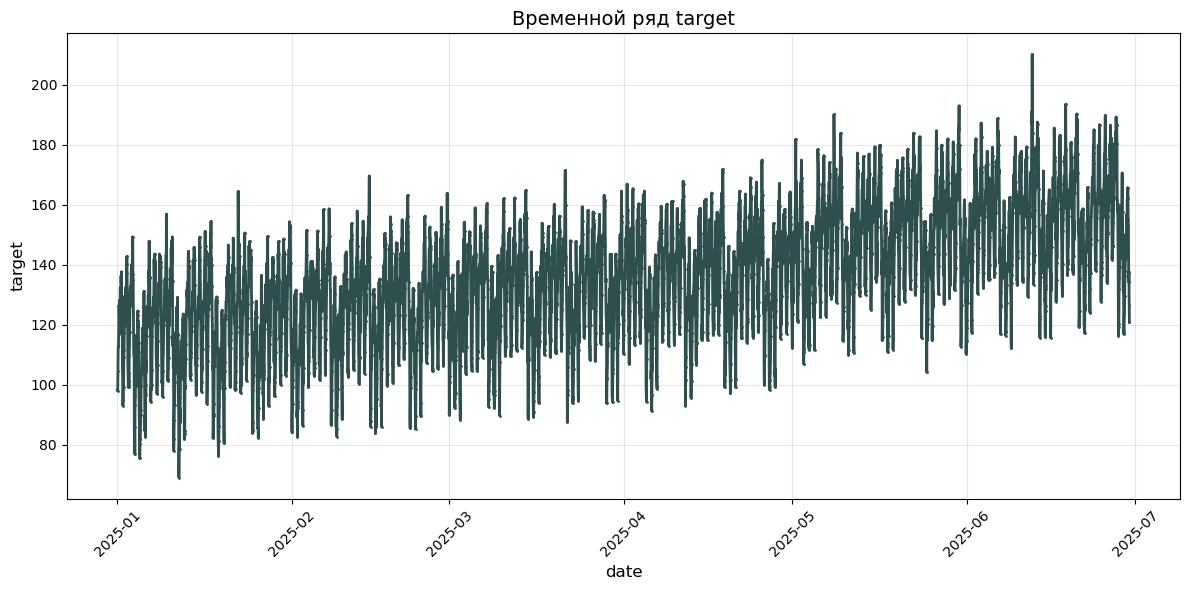

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['target'], marker='o', linestyle='-', 
         linewidth=2, markersize=1, color='darkslategrey')
plt.title('Временной ряд target', fontsize=14)
plt.xlabel('date', fontsize=12)
plt.ylabel('target', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Краткий комментарий:

1. Тренд: `линейно-восходящий`
2. Сезонность: `присутствует`, период: `около недели`
3. Выбросы: `нет`
4. Стационарность: `нестационарный (тренд + сезонность)`

### 3. Корректный temporal split

Всего наблюдений: 4320

Train: 3456 наблюдений (80.0%)
  от 2025-01-01 00:00:00 до 2025-05-24 23:00:00

Validation: 432 наблюдений (10.0%)
  от 2025-05-25 00:00:00 до 2025-06-11 23:00:00

Test: 432 наблюдений (10.0%)
  от 2025-06-12 00:00:00 до 2025-06-29 23:00:00


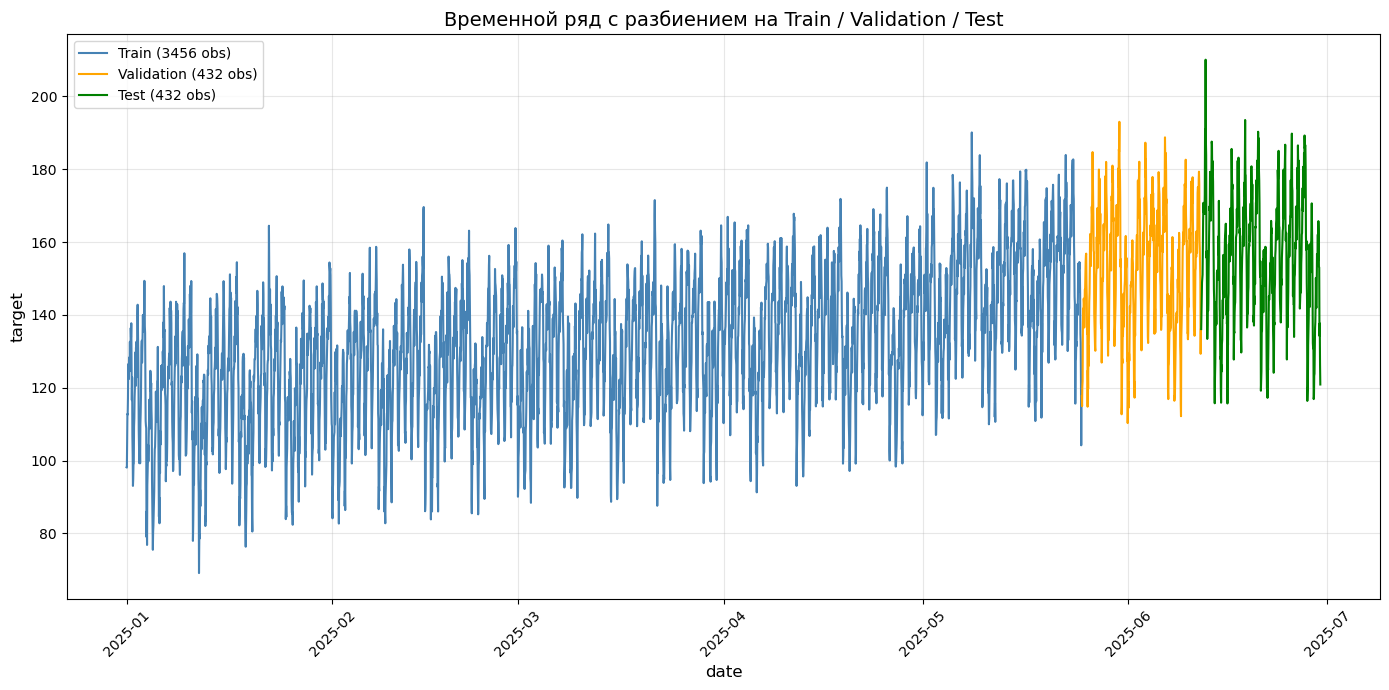

In [6]:
n = len(df)
train_end = int(n * 0.8) 
val_end = int(n * 0.9) 

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

print(f"Всего наблюдений: {n}")
print(f"\nTrain: {len(train)} наблюдений ({len(train)/n*100:.1f}%)")
print(f"  от {train['date'].min()} до {train['date'].max()}")
print(f"\nValidation: {len(val)} наблюдений ({len(val)/n*100:.1f}%)")
print(f"  от {val['date'].min()} до {val['date'].max()}")
print(f"\nTest: {len(test)} наблюдений ({len(test)/n*100:.1f}%)")
print(f"  от {test['date'].min()} до {test['date'].max()}")

# 3. Визуальное отображение участков ряда
plt.figure(figsize=(14, 7))

# Разные цвета для разных выборок
plt.plot(train['date'], train['target'], 
         color='steelblue', label=f'Train ({len(train)} obs)', linewidth=1.5)
plt.plot(val['date'], val['target'], 
         color='orange', label=f'Validation ({len(val)} obs)', linewidth=1.5)
plt.plot(test['date'], test['target'], 
         color='green', label=f'Test ({len(test)} obs)', linewidth=1.5)

# Оформление
plt.title('Временной ряд с разбиением на Train / Validation / Test', fontsize=14)
plt.xlabel('date', fontsize=12)
plt.ylabel('target', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

Random split неприменим при оценке временных рядов, потому что такое разбиение разрушает зависимости между соседними наблюдениями, модель получает информацию из "будущего" для предсказания "прошлого", что приводит к переоценке реальной производительности

### 4. Признаки для baseline-моделей

In [7]:
def create_features(df):
    """
    Создает признаки в исходном масштабе
    """
    df_features = df.copy()
    
    # 1. LAG-признаки (в исходном масштабе)
    df_features['lag_1'] = df_features['target'].shift(1)
    df_features['lag_7'] = df_features['target'].shift(7)
    df_features['lag_14'] = df_features['target'].shift(14)
    
    # 2. ROLLING-признаки (в исходном масштабе)
    df_features['rolling_mean_7'] = df_features['target'].shift(1).rolling(window=7, min_periods=1).mean()
    df_features['rolling_std_7'] = df_features['target'].shift(1).rolling(window=7, min_periods=1).std()
    
    # 3. КАЛЕНДАРНЫЕ признаки
    df_features['hour'] = df_features['date'].dt.hour
    df_features['day_of_week'] = df_features['date'].dt.dayofweek
    df_features['day_of_month'] = df_features['date'].dt.day
    df_features['month'] = df_features['date'].dt.month
    
    # Циклическое кодирование
    df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
    df_features['dow_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['dow_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)
    
    return df_features

In [8]:
train_raw = create_features(train)
val_raw = create_features(val)
test_raw = create_features(test)

train_raw = train_raw.iloc[14:].reset_index(drop=True)
val_raw = val_raw.iloc[14:].reset_index(drop=True)
test_raw = test_raw.iloc[14:].reset_index(drop=True)

print(f"\nРазмеры выборок после создания признаков:")
print(f"  Train:      {len(train_raw)} строк")
print(f"  Validation: {len(val_raw)} строк")
print(f"  Test:       {len(test_raw)} строк")


Размеры выборок после создания признаков:
  Train:      3442 строк
  Validation: 418 строк
  Test:       418 строк


In [9]:
# Список признаков для масштабирования
feature_columns = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                   'hour', 'day_of_week', 'day_of_month', 'month',
                   'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

# Обучаем scaler только на train
scaler = StandardScaler()
train_scaled = train_raw.copy()
train_scaled[feature_columns] = scaler.fit_transform(train_raw[feature_columns])

target_scaler = StandardScaler()
target_scaler.fit(train_raw[['target']])

# Применяем к validation и test
val_scaled = val_raw.copy()
val_scaled[feature_columns] = scaler.transform(val_raw[feature_columns])

test_scaled = test_raw.copy()
test_scaled[feature_columns] = scaler.transform(test_raw[feature_columns])

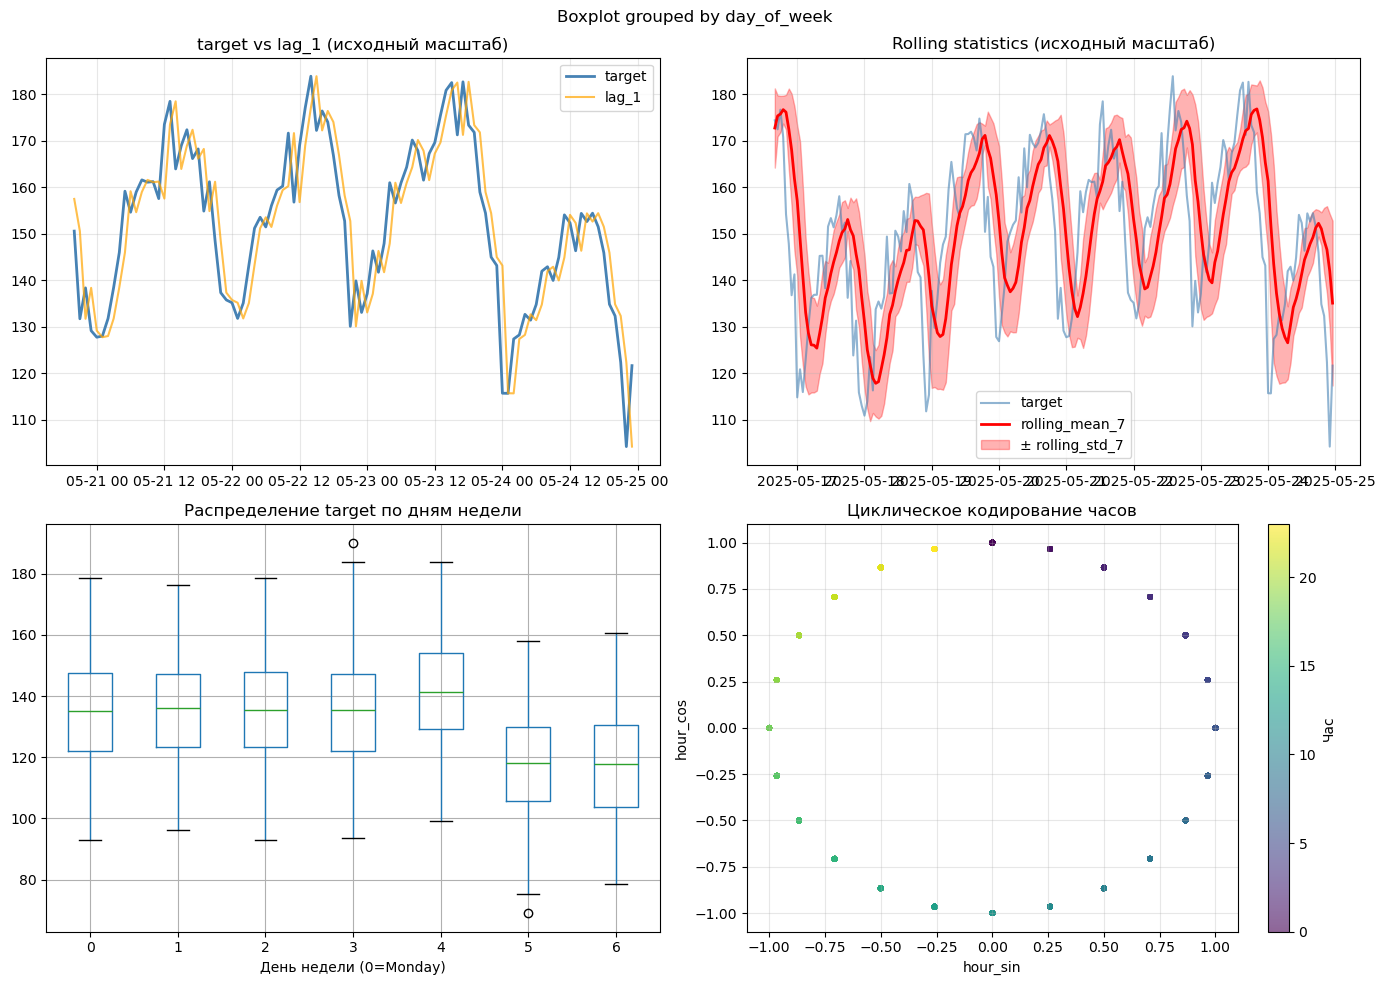

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: target и lag_1
ax1 = axes[0, 0]
ax1.plot(train_raw['date'][-100:], train_raw['target'][-100:], 
         label='target', linewidth=2, color='steelblue')
ax1.plot(train_raw['date'][-100:], train_raw['lag_1'][-100:], 
         label='lag_1', linewidth=1.5, color='orange', alpha=0.7)
ax1.set_title('target vs lag_1 (исходный масштаб)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Rolling статистика
ax2 = axes[0, 1]
ax2.plot(train_raw['date'][-200:], train_raw['target'][-200:], 
         label='target', linewidth=1.5, color='steelblue', alpha=0.6)
ax2.plot(train_raw['date'][-200:], train_raw['rolling_mean_7'][-200:], 
         label='rolling_mean_7', linewidth=2, color='red')
ax2.fill_between(train_raw['date'][-200:], 
                  train_raw['rolling_mean_7'][-200:] - train_raw['rolling_std_7'][-200:],
                  train_raw['rolling_mean_7'][-200:] + train_raw['rolling_std_7'][-200:],
                  alpha=0.3, color='red', label='± rolling_std_7')
ax2.set_title('Rolling statistics (исходный масштаб)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Распределение по дням недели
ax3 = axes[1, 0]
train_raw.boxplot(column='target', by='day_of_week', ax=ax3)
ax3.set_title('Распределение target по дням недели')
ax3.set_xlabel('День недели (0=Monday)')

# График 4: Циклическое кодирование
ax4 = axes[1, 1]
scatter = ax4.scatter(train_raw['hour_sin'], train_raw['hour_cos'], 
                      c=train_raw['hour'], cmap='viridis', alpha=0.6, s=10)
ax4.set_title('Циклическое кодирование часов')
ax4.set_xlabel('hour_sin')
ax4.set_ylabel('hour_cos')
plt.colorbar(scatter, ax=ax4, label='Час')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Оконное представление для GRU

In [11]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size=24):
        self.data = data
        self.window_size = window_size
    
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        X = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(X), torch.FloatTensor([y])

# Параметры
WINDOW_SIZE = 24
BATCH_SIZE = 32

# Создание датасетов
train_dataset = TimeSeriesDataset(train_scaled['target'].values, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(val_scaled['target'].values, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(test_scaled['target'].values, WINDOW_SIZE)

# Создание DataLoader (shuffle=False для временных рядов)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Проверка
print(f"Train samples: {len(train_dataset)}, Batches: {len(train_loader)}")
print(f"Val samples: {len(val_dataset)}, Batches: {len(val_loader)}")
print(f"Test samples: {len(test_dataset)}, Batches: {len(test_loader)}")

# Пример батча
X_batch, y_batch = next(iter(train_loader))
print(f"X shape: {X_batch.shape}, y shape: {y_batch.shape}")

Train samples: 3418, Batches: 107
Val samples: 394, Batches: 13
Test samples: 394, Batches: 13
X shape: torch.Size([32, 24]), y shape: torch.Size([32, 1])


### 6. Базовые функции обучения и оценки

In [12]:
# Получение последовательностей
def get_sequences(data):
    X, y = [], []
    for i in range(len(data) - WINDOW_SIZE):
        X.append(data[i:i+WINDOW_SIZE])
        y.append(data[i+WINDOW_SIZE])
    return np.array(X), np.array(y)

train_X, train_y = get_sequences(train_scaled['target'].values)
val_X, val_y = get_sequences(val_scaled['target'].values)
test_X, test_y = get_sequences(test_scaled['target'].values)

In [13]:
def train_gru(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    best_val_mae = float('inf')
    best_state = None
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X, y in train_loader:
            # X, y = X.unsqueeze(-1).to(device), y.to(device)
            X = X.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for X, y in val_loader:
                # X, y = X.unsqueeze(-1).to(device), y.to(device)
                X = X.to(device)
                y = y.to(device)
                pred = model(X)
                val_loss += criterion(pred, y).item()
                val_preds.append(pred.cpu().numpy())
                val_targets.append(y.cpu().numpy())
        
        val_preds = np.concatenate(val_preds).flatten()
        val_targets = np.concatenate(val_targets).flatten()
        val_mae = mean_absolute_error(val_targets, val_preds)
        
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_mae'].append(val_mae)
        
        # Сохранение лучшей модели
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {history['train_loss'][-1]:.4f}, Val MAE: {val_mae:.4f}")
    
    model.load_state_dict(best_state)
    return model, history

In [14]:
# Метрики
def calculate_metrics(y_true, y_pred):
    """y_true и y_pred в исходном масштабе"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

In [15]:
def evaluate_model(y_true_scaled, y_pred_scaled, name, scaler):
    """Оценка модели с обратным масштабированием"""
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    metrics = calculate_metrics(y_true, y_pred)
    print(f"{name}: MAE={metrics['mae']:.2f}, RMSE={metrics['rmse']:.2f}, MAPE={metrics['mape']:.2f}%")
    return metrics

## Эксперименты

In [16]:
# B1: Naive Last
def naive_last_predict(train_y, val_y, test_y):
    """Прогноз = последнее известное значение"""
    val_pred = np.array([train_y[-1]] * len(val_y))
    return val_pred

In [17]:
# B2: Moving Average
def moving_average_predict(train_y, val_y, test_y, window=24):
    """Прогноз = среднее за последние window значений"""
    last_window = train_y[-window:]
    val_pred = np.array([np.mean(last_window)] * len(val_y))
    return val_pred

In [18]:
# B3: Ridge на признаках
def create_features_for_ridge(X):
    """X: (n_samples, window_size)"""
    n_samples, window = X.shape
    features = []
    for i in range(n_samples):
        seq = X[i]
        feat = {
            'lag_1': seq[-1],
            'lag_7': seq[-7] if window >= 7 else seq[0],
            'lag_14': seq[-14] if window >= 14 else seq[0],
            'mean_7': np.mean(seq[-7:]),
            'std_7': np.std(seq[-7:]),
            'mean_14': np.mean(seq[-14:]),
            'std_14': np.std(seq[-14:]),
            'trend': seq[-1] - seq[0],
        }
        features.append(feat)
    return pd.DataFrame(features)

In [19]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        out = out[:, -1, :]  # последний выход
        return self.fc(out)

In [20]:
results = []
HORIZON = 1
EPOCHS = 50
LR = 0.001
HIDDEN_SIZE = 64
NUM_LAYERS = 2

# B1: Naive Last
val_pred_naive = naive_last_predict(train_y, val_y, test_y)
val_metrics_b1 = evaluate_model(val_y, val_pred_naive, "B1 (Naive Last) - val", target_scaler)

results.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'hourly_target',
    'seed': SEED,
    'split_summary': '70/15/15',
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': 'naive_last',
    'features_summary': 'none',
    'scaler': 'StandardScaler',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b1['mae'],
    'best_val_rmse': val_metrics_b1['rmse'],
    'best_val_mape': val_metrics_b1['mape'],
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'baseline: прогноз = последнее значение из train'
})

B1 (Naive Last) - val: MAE=641.19, RMSE=715.94, MAPE=19.42%


In [21]:
# B2: Moving Average
val_pred_ma = moving_average_predict(train_y, val_y, test_y, window=24)
val_metrics_b2 = evaluate_model(val_y, val_pred_ma, "B2 (Moving Average) - val", target_scaler)

results.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'hourly_target',
    'seed': SEED,
    'split_summary': '70/15/15',
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': 'moving_average_window24',
    'features_summary': 'rolling_mean_24',
    'scaler': 'StandardScaler',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b2['mae'],
    'best_val_rmse': val_metrics_b2['rmse'],
    'best_val_mape': val_metrics_b2['mape'],
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'baseline: среднее за последние 24 часа'
})

B2 (Moving Average) - val: MAE=393.64, RMSE=473.03, MAPE=11.87%


In [22]:
# B3: Ridge
train_feat = create_features_for_ridge(train_X)
val_feat = create_features_for_ridge(val_X)
test_feat = create_features_for_ridge(test_X)

ridge = Ridge(alpha=1.0)
ridge.fit(train_feat, train_y)
val_pred_ridge = ridge.predict(val_feat)
test_pred_ridge = ridge.predict(test_feat)

val_metrics_b3 = evaluate_model(val_y, val_pred_ridge, "B3 (Ridge) - val", target_scaler)

results.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'hourly_target',
    'seed': SEED,
    'split_summary': '70/15/15',
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': 'Ridge_regression',
    'features_summary': 'lag1,lag7,lag14,mean7,std7,mean14,std14,trend',
    'scaler': 'StandardScaler',
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_b3['mae'],
    'best_val_rmse': val_metrics_b3['rmse'],
    'best_val_mape': val_metrics_b3['mape'],
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'линейная модель на лаговых и статистических признаках'
})

B3 (Ridge) - val: MAE=106.83, RMSE=137.00, MAPE=3.40%


In [23]:
# R1: GRU
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(train_X).unsqueeze(-1),
    torch.FloatTensor(train_y).unsqueeze(-1)
)
val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(val_X).unsqueeze(-1),
    torch.FloatTensor(val_y).unsqueeze(-1)
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)

model, history = train_gru(model, train_loader, val_loader, EPOCHS, LR, device)

Epoch 10/50, Train Loss: 5078.0103, Val MAE: 88.6119
Epoch 20/50, Train Loss: 1108.6871, Val MAE: 48.0471
Epoch 30/50, Train Loss: 421.8879, Val MAE: 28.7753
Epoch 40/50, Train Loss: 404.7889, Val MAE: 24.6663
Epoch 50/50, Train Loss: 390.7662, Val MAE: 24.1684


In [24]:
# Оценка GRU
model.eval()
val_pred_gru = []
with torch.no_grad():
    for X, _ in val_loader:
        pred = model(X.to(device))
        val_pred_gru.append(pred.cpu().numpy())
val_pred_gru = np.concatenate(val_pred_gru).flatten()

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(test_X).unsqueeze(-1)),
    batch_size=BATCH_SIZE, shuffle=False
)

val_metrics_r1 = evaluate_model(val_y, val_pred_gru, "R1 (GRU) - val", target_scaler)

results.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'hourly_target',
    'seed': SEED,
    'split_summary': '70/15/15',
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': f'GRU_{NUM_LAYERS}layers_{HIDDEN_SIZE}hidden',
    'features_summary': f'window_{WINDOW_SIZE}_raw',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LR,
    'epochs_trained': len(history['train_loss']),
    'best_val_mae': val_metrics_r1['mae'], #min(history['val_mae']),
    'best_val_rmse': None,
    'best_val_mape': None,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': f'GRU, hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}'
})


R1 (GRU) - val: MAE=476.30, RMSE=557.34, MAPE=14.33%


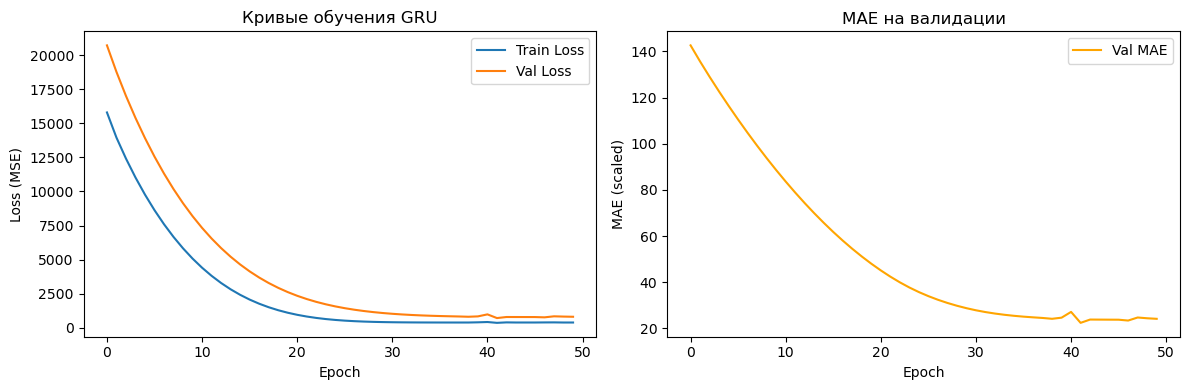

In [25]:
# Кривые обучения GRU
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Кривые обучения GRU')

plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE (scaled)')
plt.legend()
plt.title('MAE на валидации')
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

In [26]:
models_val_mae = {
    'B1': val_metrics_b1['mae'],
    'B2': val_metrics_b2['mae'],
    'B3': val_metrics_b3['mae'],
    'R1': val_metrics_r1['mae']
}

n = -10

best_model = min(models_val_mae, key=models_val_mae.get)
best_val_mae = models_val_mae[best_model]

if best_model == 'B1':
    _, test_pred_best = naive_last_predict(train_y, val_y, test_y)
    test_metrics = evaluate_model(test_y, test_pred_best, f"{best_model} (test)", target_scaler)
    n = 0

elif best_model == 'B2':
    _, test_pred_best = moving_average_predict(train_y, val_y, test_y, window=24)
    test_metrics = evaluate_model(test_y, test_pred_best, f"{best_model} (test)", target_scaler)
    n = 1
    
elif best_model == 'B3':
    test_feat = create_features_for_ridge(test_X)
    test_pred_best = ridge.predict(test_feat)
    test_metrics = evaluate_model(test_y, test_pred_best, f"{best_model} (test)", target_scaler)
    n = 2
    
elif best_model == 'R1':
    test_dataset = torch.utils.data.TensorDataset(torch.FloatTensor(test_X).unsqueeze(-1))
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    n = 3
    
    test_pred_best = []
    with torch.no_grad():
        for X in test_loader:
            if isinstance(X, (tuple, list)):
                X = X[0]
            X = X.to(device)
            pred = model(X)
            test_pred_best.append(pred.cpu().numpy())
    test_pred_best = np.concatenate(test_pred_best).flatten()
    test_metrics = evaluate_model(test_y, test_pred_best, f"{best_model} (test)", target_scaler)


results[n]['test_mae'] = test_metrics['mae']
results[n]['test_rmse'] = test_metrics['rmse']
results[n]['test_mape'] = test_metrics['mape']

B3 (test): MAE=111.29, RMSE=141.31, MAPE=3.53%


In [27]:
# runs.csv
df_results = pd.DataFrame(results)
df_results.to_csv('artifacts/runs.csv', index=False)

# best_gru.pt и config
# best_val_mae = df_results[df_results['experiment_id'] == 'R1']['best_val_mae'].values[0]
torch.save(model.state_dict(), 'artifacts/best_gru.pt')

config = {
    'model': 'GRU',
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'seed': SEED,
    'scaler_mean': float(target_scaler.mean_[0]),
    'scaler_scale': float(target_scaler.scale_[0]),
    'best_val_mae': models_val_mae['R1'] #best_val_mae
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

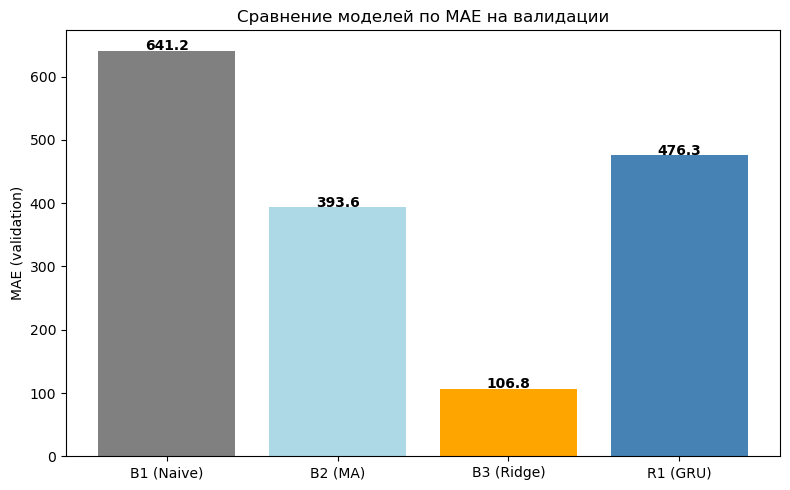

In [28]:
# Сравнение baselines
val_mae_values = [df_results[df_results['experiment_id'] == exp]['best_val_mae'].values[0] 
                  for exp in ['B1', 'B2', 'B3', 'R1']]

plt.figure(figsize=(8, 5))
bars = plt.bar(['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)'], val_mae_values, 
                color=['gray', 'lightblue', 'orange', 'steelblue'])
plt.ylabel('MAE (validation)')
plt.title('Сравнение моделей по MAE на валидации')
for bar, val in zip(bars, val_mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

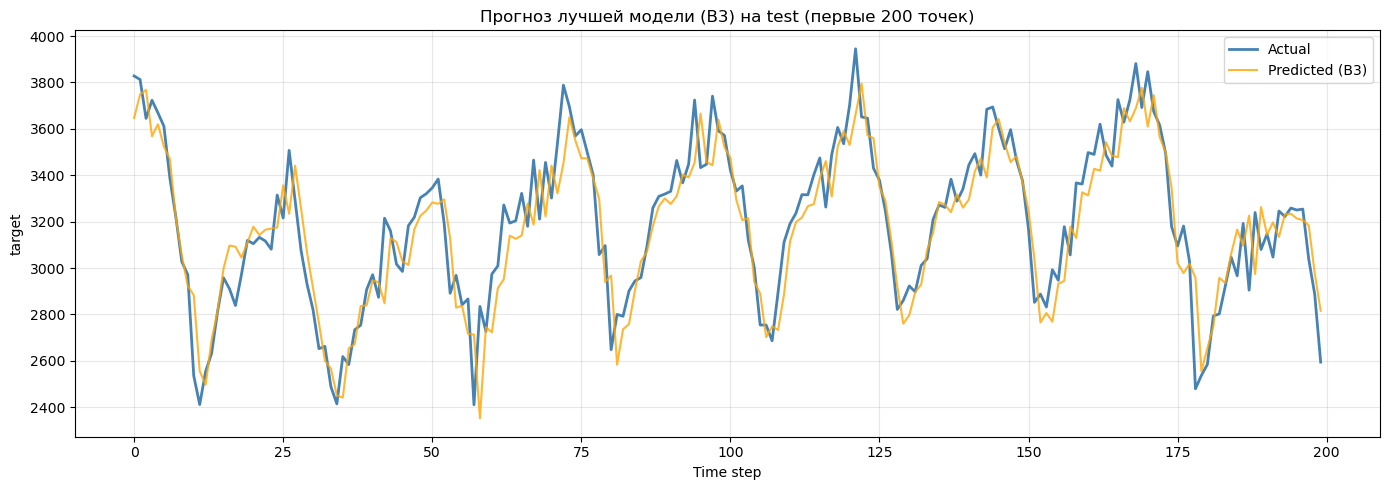


Финальная метрика B3 на test: MAE=111.29


In [29]:
y_test_orig = target_scaler.inverse_transform(test_y.reshape(-1, 1)).flatten()
y_pred_orig = target_scaler.inverse_transform(test_pred_best.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 5))
plt.plot(y_test_orig[:200], label='Actual', linewidth=2, color='steelblue')
plt.plot(y_pred_orig[:200], label=f'Predicted ({best_model})', linewidth=1.5, color='orange', alpha=0.8)
plt.xlabel('Time step')
plt.ylabel('target')
plt.title(f'Прогноз лучшей модели ({best_model}) на test (первые 200 точек)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

print(f"\nФинальная метрика {best_model} на test: MAE={test_metrics['mae']:.2f}")